<a href="https://colab.research.google.com/github/AshmiSaha/Disease_detection_trial_2.1/blob/main/Model_4_3_EfficientNetB1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls /content

sample_data


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os


zip_path = '/content/drive/MyDrive/Colab Notebooks/ham10000.zip'


extract_path = '/content/ham10000_data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
!pip install -q tensorflow scikit-learn seaborn scipy pillow

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input


from sklearn.utils import resample

print("All imports done")

All imports done


# Reading the CSV file

In [ ]:
skin_df = pd.read_csv(os.path.join(extract_path, 'HAM10000_metadata.csv'))

In [ ]:
print(skin_df.head())

print(skin_df.tail())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
         lesion_id      image_id     dx dx_type   age     sex localization
10010  HAM_0002867  ISIC_0033084  akiec   histo  40.0    male      abdomen
10011  HAM_0002867  ISIC_0033550  akiec   histo  40.0    male      abdomen
10012  HAM_0002867  ISIC_0033536  akiec   histo  40.0    male      abdomen
10013  HAM_0000239  ISIC_0032854  akiec   histo  80.0    male         face
10014  HAM_0003521  ISIC_0032258    mel   histo  70.0  female         back


In [ ]:
print("\nDisease types:", skin_df['dx'].unique())  # Listing the unique diseases. Expected output: classes = 7


Disease types: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


# Label encoding to convert text labels to numbers

In [ ]:
le = LabelEncoder()
skin_df['label'] = le.fit_transform(skin_df['dx'])

# To show the mapping
print("Class labels:")
for i, name in enumerate(le.classes_):
    print("{} -> {}".format(i,name))

Class labels:
0 -> akiec
1 -> bcc
2 -> bkl
3 -> df
4 -> mel
5 -> nv
6 -> vasc


In [ ]:
num_classes = skin_df['label'].nunique()
num_classes

7

In [ ]:
print(skin_df.sample(10))

        lesion_id      image_id     dx    dx_type   age     sex  \
3028  HAM_0007193  ISIC_0025398     nv  follow_up  45.0    male   
7582  HAM_0003735  ISIC_0032512     nv      histo  40.0  female   
2852  HAM_0000872  ISIC_0029323    bcc      histo  75.0    male   
5133  HAM_0006848  ISIC_0031129     nv  follow_up  45.0  female   
3646  HAM_0002211  ISIC_0026862     nv  follow_up  45.0  female   
3420  HAM_0006812  ISIC_0024637     nv  follow_up  55.0  female   
9939  HAM_0001277  ISIC_0031927  akiec      histo  75.0    male   
2582  HAM_0004420  ISIC_0024795    bcc      histo  55.0    male   
5929  HAM_0001937  ISIC_0032432     nv  follow_up  30.0    male   
2936  HAM_0003444  ISIC_0028687    bcc      histo  80.0  female   

         localization  label  
3028            trunk      5  
7582             back      5  
2852            chest      1  
5133             foot      5  
3646          abdomen      5  
3420            trunk      5  
9939            chest      0  
2582          

In [ ]:
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


# Data visualization using plots

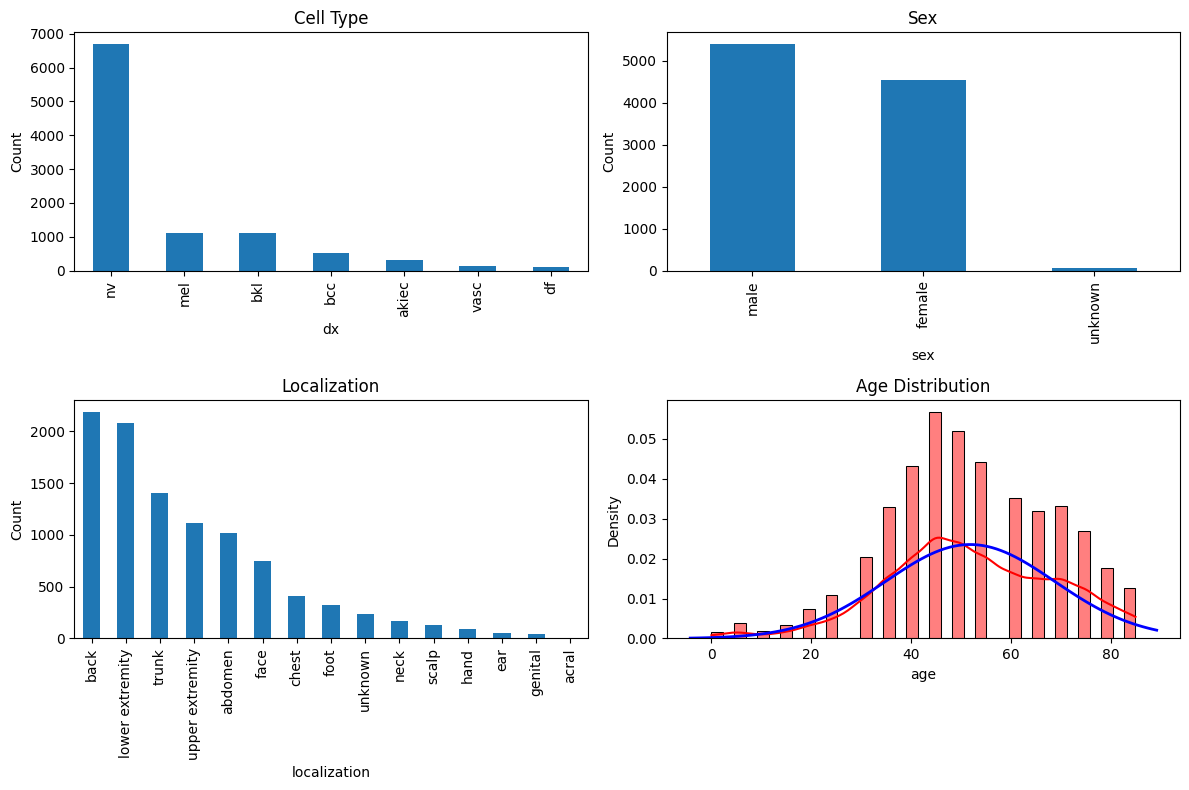

In [ ]:
fig = plt.figure(figsize=(12, 8))

# ----- Plot 1: Plotting the disease types (or Cell Types) -------
ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Type')

# ------ Plot 2: Plotting to see the distribution of gender -----
ax2 = fig.add_subplot(222)
skin_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count')
ax2.set_title('Sex')

# --- Plot 3: Plotting localization -------
ax3 = fig.add_subplot(223)
skin_df['localization'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count')
ax3.set_title('Localization')

# ----- Plot 4: Age Distribution ------
ax4 = fig.add_subplot(224)

#sample_age = skin_df[pd.notnull(skin_df['age'])]
age_data = skin_df['age'].dropna()

# Using histogram + KDE for better visualization of whether the data is symmetric or skewed
sns.histplot(age_data, kde=True, stat='density', color='red', ax=ax4)

# Displaing the fitted normal curve
mean, std_dev = stats.norm.fit(age_data)
xmin, xmax = ax4.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)

ax4.plot(x, p, linewidth=2, color = 'blue')      # the normal curve
ax4.set_title('Age Distribution')
ax4.set_xlabel('age')
ax4.set_ylabel('Density')

plt.tight_layout()
plt.show()


In the age distribution curve, we see that our data is not following the normal curve (which is blue in colour). Hence we, can infer that it is not symmetric

# Visualising the distribution of data into various classes

In [ ]:
print(type(skin_df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(skin_df.shape)

(10015, 8)


In [ ]:
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


**From the graph and the values here, we can infer that the data is imbalanced.**

# Reading all image paths (all .jpg files in both of the image folders)

In [ ]:
image_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join('ham10000_data/HAM10000_images_part_*', '*.jpg'))
}

# Adding a new column named 'path' to the dataframe
skin_df['path'] = skin_df['image_id'].map(image_path.get)

# Now, we drop the rows where image was not found
skin_df = skin_df.dropna(subset=['path'])

print(f"Total images available: {len(skin_df)}")

Total images available: 10015


In [ ]:
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   label         10015 non-null  int64  
 8   path          10015 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 704.3+ KB


Therefore, we can see that all rows have an image. In other words, there are no rows without one.

# The following shows the number of images for each disease

In [ ]:
print(skin_df['dx'].value_counts())



dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Again we can see that there is some imbalance.

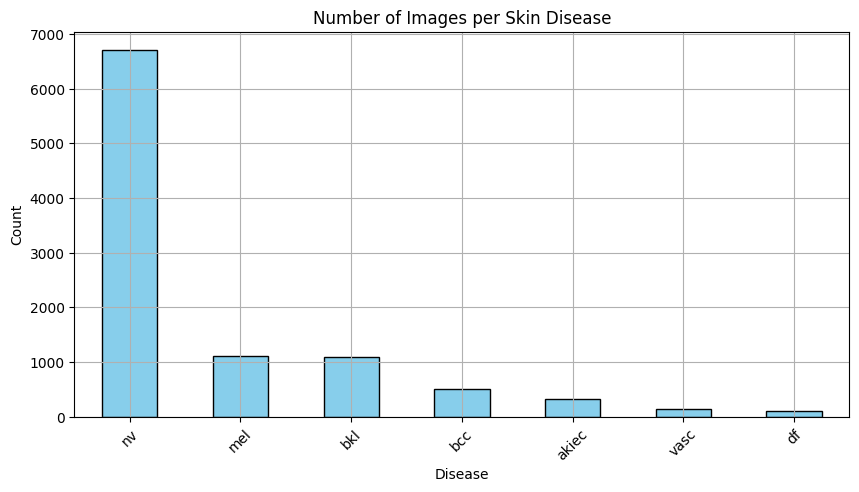

In [ ]:
# Ploting a bar chart
plt.figure(figsize=(10, 5))
skin_df['dx'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Images per Skin Disease")
plt.ylabel("Count")
plt.xlabel("Disease")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Spliting the data into 80% for training and 10% for validation and 10% for testing

In [ ]:
X_paths = skin_df['path'].values
Y = skin_df['label'].values

X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    X_paths, Y, test_size=0.10, random_state=42, stratify=Y
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.11, random_state=42, stratify=y_train_val_labels
)


In [ ]:
print("Train samples:", len(X_train_paths))
print("Train labels:", len(y_train_labels))

print("\nValidation samples:", len(X_val_paths))
print("Validation labels:", len(y_val_labels))

print("\nTest samples:", len(X_test_paths))
print("Test labels:", len(y_test_labels))


Train samples: 8021
Train labels: 8021

Validation samples: 992
Validation labels: 992

Test samples: 1002
Test labels: 1002


# Now, below we compute the class weights

Since the data is skewed, we try to compute the class weights such that the rare classes get more weightage than the common ones.

In [ ]:
cl_wgts = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
cl_wgts_dict = dict(enumerate(cl_wgts))

print("Class weights:", cl_wgts_dict)

Class weights: {0: np.float64(4.390257252326218), 1: np.float64(2.78120665742025), 2: np.float64(1.3021103896103896), 3: np.float64(12.45496894409938), 4: np.float64(1.284593209481102), 5: np.float64(0.21338121840915136), 6: np.float64(10.051378446115288)}


# **Dataframes**

In [ ]:
train_df = pd.DataFrame({'path': X_train_paths, 'label': y_train_labels.astype(str)})
val_df   = pd.DataFrame({'path': X_val_paths, 'label': y_val_labels.astype(str)})
test_df  = pd.DataFrame({'path': X_test_paths, 'label': y_test_labels.astype(str)})

# **Data Augmentation**

In [ ]:
SIZE = 224
BATCH_SIZE = 16

In [ ]:
train_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_data_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed = 42
)

val_generator = val_test_data_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_data_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8021 validated image filenames belonging to 7 classes.
Found 992 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


# Now, we build the EfficientNetB1 model

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
inputs = Input(shape=(SIZE, SIZE, 3))
base_model = EfficientNetB1(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,740,110 (25.71 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 6,575,239 (25.08 MB)

# We now set the callbacks

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_effnetb1.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

### Explanation for myself:

The **ReduceLROnPlateau** monitors our model's accuracy on validation data i.e., *monitor='val_accuracy'*. If this accuracy doesnot improve for like 3 epochs in a row, since *patience=3*, it reduces the learning rate into half, since *factor=0.5*.

The **EarlyStopping** also watches the *val_accuracy*. and if that doesnot get better for 7 consecutive epochs, since *patience=7*, it completely stops the training. This then loads the model's best weights from earlier, since we do: *restore_best_weights=True*, so we donot have to end up with an overfitted or even a worse version.

## Model Training

In [ ]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.3566 - loss: 1.9118
Epoch 1: val_loss improved from None to 1.19891, saving model to best_effnetb1.keras

Epoch 1: finished saving model to best_effnetb1.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 248s 407ms/step - accuracy: 0.4210 - loss: 1.6567 - val_accuracy: 0.5202 - val_loss: 1.1989 - learning_rate: 0.0010
Epoch 2/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.4751 - loss: 1.3843
Epoch 2: val_loss improved from 1.19891 to 1.14688, saving model to best_effnetb1.keras

Epoch 2: finished saving model to best_effnetb1.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 302ms/step - accuracy: 0.4977 - loss: 1.3474 - val_accuracy: 0.5554 - val_loss: 1.1469 - learning_rate: 0.0010
Epoch 3/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5378 - loss: 1.2606
Epoch 3: val_loss did not improve from 1.14688
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 303ms/step - accuracy: 0.5220 - loss: 1.2646 - val_accuracy: 0.5181 - val_loss: 1.

# Fine Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6256 - loss: 0.9768
Epoch 1: val_loss improved from 0.80191 to 0.78281, saving model to best_effnetb1.keras

Epoch 1: finished saving model to best_effnetb1.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 224s 373ms/step - accuracy: 0.6149 - loss: 0.9796 - val_accuracy: 0.6976 - val_loss: 0.7828 - learning_rate: 1.0000e-05
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.6245 - loss: 0.9150
Epoch 2: val_loss improved from 0.78281 to 0.77047, saving model to best_effnetb1.keras

Epoch 2: finished saving model to best_effnetb1.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 303ms/step - accuracy: 0.6272 - loss: 0.9122 - val_accuracy: 0.7087 - val_loss: 0.7705 - learning_rate: 1.0000e-05
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6154 - loss: 0.9498
Epoch 3: val_loss did not improve from 0.77047
502/502 ━━━━━━━━━━━━━━━━━━━━ 150s 299ms/step - accuracy: 0.6199 - loss: 0.9226 - val_accuracy: 0.6956 - v

# We finally plot the resuts

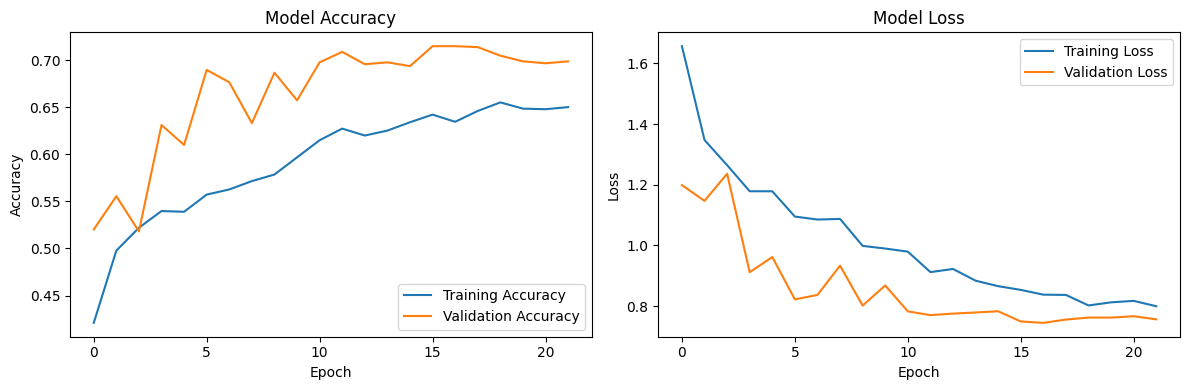

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history.get('accuracy', []) + history2.history.get('accuracy', []), label='Training Accuracy')
plt.plot(history1.history.get('val_accuracy', []) + history2.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history.get('loss', []) + history2.history.get('loss', []), label='Training Loss')
plt.plot(history1.history.get('val_loss', []) + history2.history.get('val_loss', []), label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Test eval

Test Loss: 0.8250883221626282
Test Accuracy: 0.6666666865348816
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 282ms/step


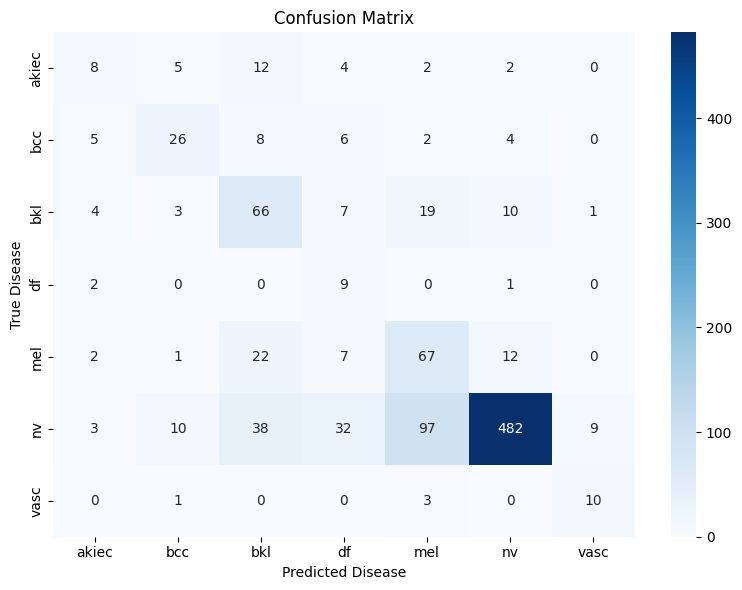


Classification Report:
              precision    recall  f1-score   support

       akiec       0.33      0.24      0.28        33
         bcc       0.57      0.51      0.54        51
         bkl       0.45      0.60      0.52       110
          df       0.14      0.75      0.23        12
         mel       0.35      0.60      0.45       111
          nv       0.94      0.72      0.82       671
        vasc       0.50      0.71      0.59        14

    accuracy                           0.67      1002
   macro avg       0.47      0.59      0.49      1002
weighted avg       0.77      0.67      0.70      1002



In [ ]:
score = model.evaluate(test_generator, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

Accuracy = 66%

In [ ]:
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


Now we save the model so that we donot have to run the full code everyime when we wish to predict the disease

In [ ]:
model.save('efficientnetb1_&finetuned.keras')
print("Model saved as efficientnetb1_&finetuned.keras")

Model saved as efficientnetb1_&finetuned.keras


## Now we use **EfficientNetB2**

In [ ]:
from tensorflow.keras.applications import EfficientNetB2

In [ ]:
inputs = Input(shape=(SIZE, SIZE, 3))
base_model = EfficientNetB2(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 7,949,824 (30.33 MB)

 Trainable params: 181,255 (708.03 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_effnetb2.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.3878 - loss: 1.7445
Epoch 1: val_loss improved from None to 1.26444, saving model to best_effnetb2.h5



Epoch 1: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 251s 414ms/step - accuracy: 0.4213 - loss: 1.5630 - val_accuracy: 0.4637 - val_loss: 1.2644 - learning_rate: 0.0010
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4763 - loss: 1.2969
Epoch 2: val_loss improved from 1.26444 to 0.97702, saving model to best_effnetb2.h5



Epoch 2: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 159s 316ms/step - accuracy: 0.4996 - loss: 1.2735 - val_accuracy: 0.6321 - val_loss: 0.9770 - learning_rate: 0.0010
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5422 - loss: 1.2128
Epoch 3: val_loss did not improve from 0.97702
502/502 ━━━━━━━━━━━━━━━━━━━━ 150s 298ms/step - accuracy: 0.5255 - loss: 1.2073 - val_accuracy: 0.6048 - val_loss: 0.9921 - learning_rate: 0.0010
Epoch 4/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5326 - loss: 1.1514
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_loss did not improve from 0.97702
502/502 ━━━━━━━━━━━━━━━━━━━━ 151s 301ms/step - accuracy: 0.5361 - loss: 1.1361 - val_accuracy: 0.5948 - val_loss: 1.0030 - learning_rate: 0.0010
Epoch 5/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.5312 - loss: 1.0896
Epoch 5: val_loss improved from 0.97702 to 0.88875, saving model to best_effne


Epoch 5: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 150s 299ms/step - accuracy: 0.5583 - loss: 1.0753 - val_accuracy: 0.6391 - val_loss: 0.8888 - learning_rate: 5.0000e-04
Epoch 6/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5762 - loss: 1.0716
Epoch 6: val_loss improved from 0.88875 to 0.87064, saving model to best_effnetb2.h5



Epoch 6: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 305ms/step - accuracy: 0.5703 - loss: 1.0646 - val_accuracy: 0.6825 - val_loss: 0.8706 - learning_rate: 5.0000e-04
Epoch 7/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5997 - loss: 0.9933
Epoch 7: val_loss improved from 0.87064 to 0.80155, saving model to best_effnetb2.h5



Epoch 7: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 305ms/step - accuracy: 0.5961 - loss: 0.9826 - val_accuracy: 0.7016 - val_loss: 0.8015 - learning_rate: 5.0000e-04
Epoch 8/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5953 - loss: 0.9798
Epoch 8: val_loss did not improve from 0.80155
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 303ms/step - accuracy: 0.5932 - loss: 0.9718 - val_accuracy: 0.6613 - val_loss: 0.8786 - learning_rate: 5.0000e-04
Epoch 9/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5896 - loss: 0.9786
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_loss did not improve from 0.80155
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 303ms/step - accuracy: 0.5976 - loss: 0.9823 - val_accuracy: 0.6683 - val_loss: 0.8606 - learning_rate: 5.0000e-04
Epoch 10/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5958 - loss: 0.9483
Epoch 10: val_loss did not improve from 0.80155
502/502 ━━━━━━━━━

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6232 - loss: 0.9377
Epoch 1: val_loss did not improve from 0.80155
502/502 ━━━━━━━━━━━━━━━━━━━━ 239s 400ms/step - accuracy: 0.6073 - loss: 0.9644 - val_accuracy: 0.6935 - val_loss: 0.8115 - learning_rate: 1.0000e-05
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6187 - loss: 0.9114
Epoch 2: val_loss improved from 0.80155 to 0.79063, saving model to best_effnetb2.h5



Epoch 2: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 196s 310ms/step - accuracy: 0.6154 - loss: 0.9085 - val_accuracy: 0.6845 - val_loss: 0.7906 - learning_rate: 1.0000e-05
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.6248 - loss: 0.8781
Epoch 3: val_loss did not improve from 0.79063
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 304ms/step - accuracy: 0.6180 - loss: 0.8820 - val_accuracy: 0.6774 - val_loss: 0.8475 - learning_rate: 1.0000e-05
Epoch 4/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6187 - loss: 0.8646
Epoch 4: val_loss improved from 0.79063 to 0.78107, saving model to best_effnetb2.h5



Epoch 4: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 155s 310ms/step - accuracy: 0.6272 - loss: 0.8647 - val_accuracy: 0.7026 - val_loss: 0.7811 - learning_rate: 1.0000e-05
Epoch 5/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6244 - loss: 0.8352
Epoch 5: val_loss improved from 0.78107 to 0.75216, saving model to best_effnetb2.h5



Epoch 5: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 156s 310ms/step - accuracy: 0.6279 - loss: 0.8508 - val_accuracy: 0.6986 - val_loss: 0.7522 - learning_rate: 1.0000e-05
Epoch 6/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6502 - loss: 0.8040
Epoch 6: val_loss improved from 0.75216 to 0.74824, saving model to best_effnetb2.h5



Epoch 6: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 302ms/step - accuracy: 0.6480 - loss: 0.8176 - val_accuracy: 0.7087 - val_loss: 0.7482 - learning_rate: 1.0000e-05
Epoch 7/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6442 - loss: 0.8275
Epoch 7: val_loss did not improve from 0.74824
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 304ms/step - accuracy: 0.6443 - loss: 0.8442 - val_accuracy: 0.7127 - val_loss: 0.7545 - learning_rate: 1.0000e-05
Epoch 8/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6614 - loss: 0.7687
Epoch 8: val_loss improved from 0.74824 to 0.72827, saving model to best_effnetb2.h5



Epoch 8: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 152s 302ms/step - accuracy: 0.6524 - loss: 0.7959 - val_accuracy: 0.7077 - val_loss: 0.7283 - learning_rate: 1.0000e-05
Epoch 9/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6452 - loss: 0.7745
Epoch 9: val_loss did not improve from 0.72827
502/502 ━━━━━━━━━━━━━━━━━━━━ 151s 301ms/step - accuracy: 0.6488 - loss: 0.7965 - val_accuracy: 0.6895 - val_loss: 0.7697 - learning_rate: 1.0000e-05
Epoch 10/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6595 - loss: 0.7498
Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 10: val_loss did not improve from 0.72827
502/502 ━━━━━━━━━━━━━━━━━━━━ 151s 302ms/step - accuracy: 0.6517 - loss: 0.7815 - val_accuracy: 0.6613 - val_loss: 0.8096 - learning_rate: 1.0000e-05
Epoch 11/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.6373 - loss: 0.7526
Epoch 11: val_loss did not improve from 0.72827
502/502 ━━━━━━


Epoch 12: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 306ms/step - accuracy: 0.6618 - loss: 0.7449 - val_accuracy: 0.7157 - val_loss: 0.7165 - learning_rate: 5.0000e-06
Epoch 13/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6690 - loss: 0.7635
Epoch 13: val_loss improved from 0.71648 to 0.71038, saving model to best_effnetb2.h5



Epoch 13: finished saving model to best_effnetb2.h5
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 304ms/step - accuracy: 0.6694 - loss: 0.7477 - val_accuracy: 0.7188 - val_loss: 0.7104 - learning_rate: 5.0000e-06
Epoch 14/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6544 - loss: 0.7592
Epoch 14: val_loss did not improve from 0.71038
502/502 ━━━━━━━━━━━━━━━━━━━━ 154s 307ms/step - accuracy: 0.6599 - loss: 0.7639 - val_accuracy: 0.7167 - val_loss: 0.7203 - learning_rate: 5.0000e-06
Epoch 15/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6595 - loss: 0.7382
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 15: val_loss did not improve from 0.71038
502/502 ━━━━━━━━━━━━━━━━━━━━ 153s 304ms/step - accuracy: 0.6651 - loss: 0.7478 - val_accuracy: 0.7188 - val_loss: 0.7168 - learning_rate: 5.0000e-06


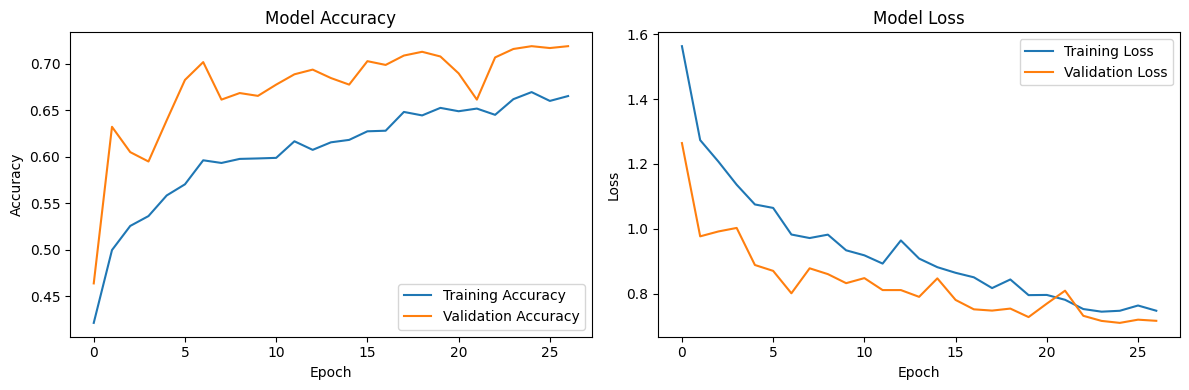

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history.get('accuracy', []) + history2.history.get('accuracy', []), label='Training Accuracy')
plt.plot(history1.history.get('val_accuracy', []) + history2.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history.get('loss', []) + history2.history.get('loss', []), label='Training Loss')
plt.plot(history1.history.get('val_loss', []) + history2.history.get('val_loss', []), label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.7806976437568665
Test Accuracy: 0.71856290102005
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 271ms/step


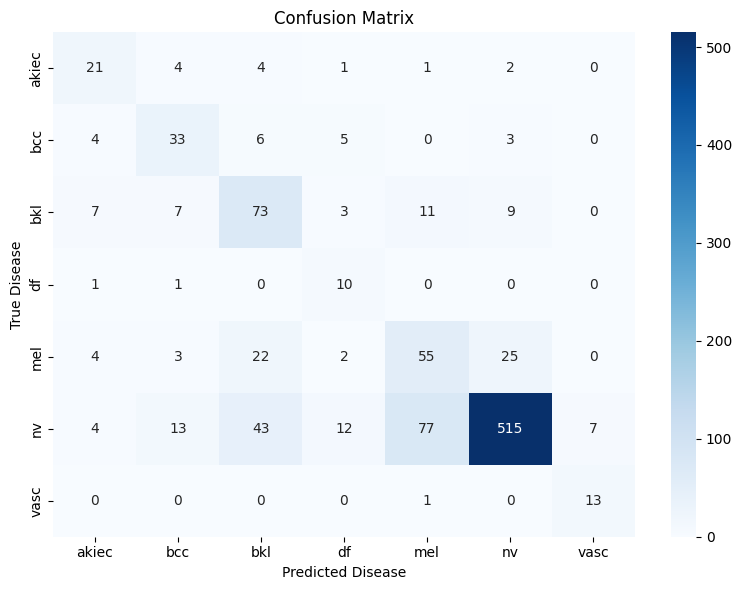


Classification Report:
              precision    recall  f1-score   support

       akiec       0.51      0.64      0.57        33
         bcc       0.54      0.65      0.59        51
         bkl       0.49      0.66      0.57       110
          df       0.30      0.83      0.44        12
         mel       0.38      0.50      0.43       111
          nv       0.93      0.77      0.84       671
        vasc       0.65      0.93      0.76        14

    accuracy                           0.72      1002
   macro avg       0.54      0.71      0.60      1002
weighted avg       0.78      0.72      0.74      1002



In [ ]:
score = model.evaluate(test_generator, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

In [ ]:
model.save('efficientnetb2_&finetuned.h5')
model.save("efficientnetb2_&finetuned.keras")
print("Model saved as .h5 and as .keras format")

Model saved as .h5 and as .keras format


In [ ]:
pip show keras

Name: keras
Version: 3.13.2
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: keras-hub, tensorflow


In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
model.save('/content/drive/MyDrive/efficientnetb2_&finetuned.h5')

In [ ]:
model.save('/content/drive/MyDrive/efficientnetb2_&finetuned.keras')

# **EfficientB3**

In [ ]:
from tensorflow.keras.applications import EfficientNetB3

In [ ]:
inputs = Input(shape=(SIZE, SIZE, 3))
base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 10,981,174 (41.89 MB)

 Trainable params: 197,639 (772.03 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_effnetb3.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.3895 - loss: 1.7649
Epoch 1: val_loss improved from None to 1.36779, saving model to best_effnetb3.keras

Epoch 1: finished saving model to best_effnetb3.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 268s 434ms/step - accuracy: 0.4230 - loss: 1.6474 - val_accuracy: 0.4264 - val_loss: 1.3678 - learning_rate: 0.0010
Epoch 2/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.4928 - loss: 1.3656
Epoch 2: val_loss improved from 1.36779 to 1.17957, saving model to best_effnetb3.keras

Epoch 2: finished saving model to best_effnetb3.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 166s 330ms/step - accuracy: 0.4882 - loss: 1.3658 - val_accuracy: 0.5312 - val_loss: 1.1796 - learning_rate: 0.0010
Epoch 3/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5012 - loss: 1.2339
Epoch 3: val_loss improved from 1.17957 to 1.07298, saving model to best_effnetb3.keras

Epoch 3: finished saving model to best_effnetb3.keras
502/502 ━━━━━━━━━━━━

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=cl_wgts_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5776 - loss: 1.1533
Epoch 1: val_loss did not improve from 0.87225
502/502 ━━━━━━━━━━━━━━━━━━━━ 248s 406ms/step - accuracy: 0.5822 - loss: 1.0810 - val_accuracy: 0.6391 - val_loss: 0.9223 - learning_rate: 1.0000e-05
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6031 - loss: 1.0797
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_loss did not improve from 0.87225
502/502 ━━━━━━━━━━━━━━━━━━━━ 168s 334ms/step - accuracy: 0.5972 - loss: 1.0278 - val_accuracy: 0.6411 - val_loss: 0.9249 - learning_rate: 1.0000e-05
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6016 - loss: 0.9879
Epoch 3: val_loss improved from 0.87225 to 0.86058, saving model to best_effnetb3.keras

Epoch 3: finished saving model to best_effnetb3.keras
502/502 ━━━━━━━━━━━━━━━━━━━━ 165s 328ms/step - accuracy: 0.6047 - loss: 0.9889 - val_accuracy: 0.6603 - val_loss: 0.8606 - l

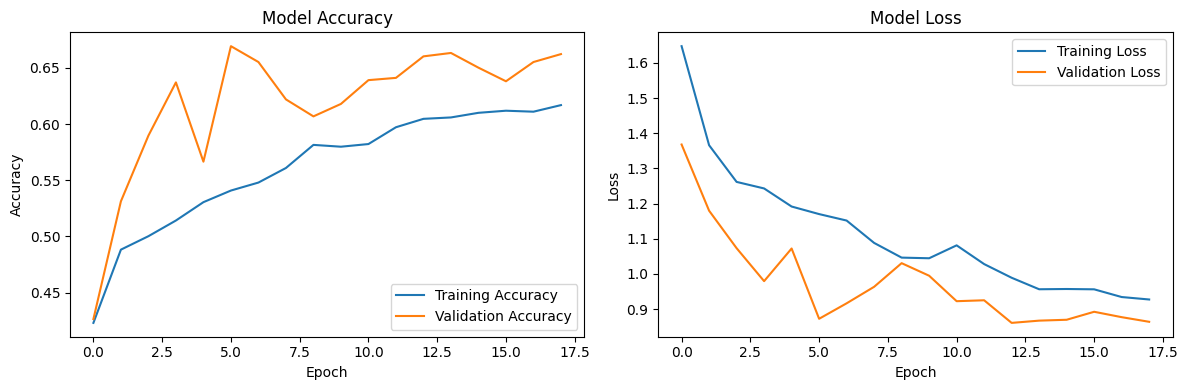

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history.get('accuracy', []) + history2.history.get('accuracy', []), label='Training Accuracy')
plt.plot(history1.history.get('val_accuracy', []) + history2.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history.get('loss', []) + history2.history.get('loss', []), label='Training Loss')
plt.plot(history1.history.get('val_loss', []) + history2.history.get('val_loss', []), label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.9280477166175842
Test Accuracy: 0.6506986021995544
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step


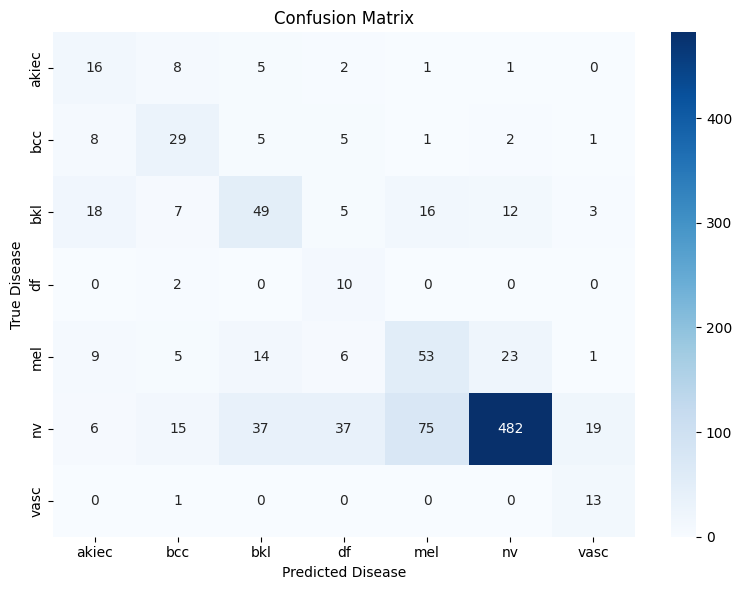


Classification Report:
              precision    recall  f1-score   support

       akiec       0.28      0.48      0.36        33
         bcc       0.43      0.57      0.49        51
         bkl       0.45      0.45      0.45       110
          df       0.15      0.83      0.26        12
         mel       0.36      0.48      0.41       111
          nv       0.93      0.72      0.81       671
        vasc       0.35      0.93      0.51        14

    accuracy                           0.65      1002
   macro avg       0.42      0.64      0.47      1002
weighted avg       0.75      0.65      0.68      1002



In [ ]:
score = model.evaluate(test_generator, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

In [ ]:
model.save('efficientnetb3_&finetuned.keras')
print("Model saved as efficientnetb3_&finetuned.keras")

Model saved as efficientnetb3_&finetuned.keras


# Testing with an image

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = '/content/basal-cell-carcinoma-0087.jpg'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
pred_class = np.argmax(preds, axis=1)[0]
pred_label = le.inverse_transform([pred_class])[0]

print("Predicted class:", pred_label)
print("Probabilities:", preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
Predicted class: vasc
Probabilities: [0.01731843 0.2500392  0.15454525 0.05208866 0.05827687 0.16158007
 0.30615157]


In [ ]:
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


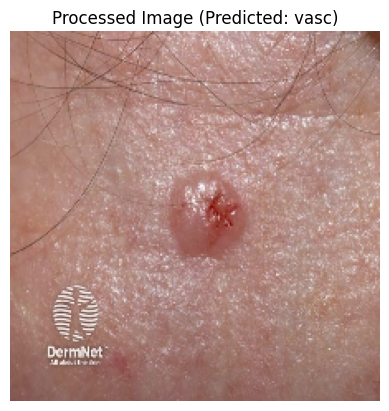

In [ ]:
plt.imshow(img)
plt.title(f"Processed Image (Predicted: {pred_label})")
plt.axis('off')
plt.show()